In [ ]:
import pandas as pd

train_set = pd.read_csv(
    "../data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=cols
)

train_set.head()


,engine_id,cycle,op1,op2,op3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
from scipy.optimize import minimize

In [4]:
cols = ['engine_id', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]

In [7]:
train_set.shape


(20631, 26)

In [8]:
test_set.shape

(13096, 26)

In [9]:
#getting the failure time for each engine in the training set
failure_time=train_set.groupby('engine_id')['cycle'].max().values
failure_time

array([192, 287, 179, 189, 269, 188, 259, 150, 201, 222, 240, 170, 163,
       180, 207, 209, 276, 195, 158, 234, 195, 202, 168, 147, 230, 199,
       156, 165, 163, 194, 234, 191, 200, 195, 181, 158, 170, 194, 128,
       188, 216, 196, 207, 192, 158, 256, 214, 231, 215, 198, 213, 213,
       195, 257, 193, 275, 137, 147, 231, 172, 185, 180, 174, 283, 153,
       202, 313, 199, 362, 137, 208, 213, 213, 166, 229, 210, 154, 231,
       199, 185, 240, 214, 293, 267, 188, 278, 178, 213, 217, 154, 135,
       341, 155, 258, 283, 336, 202, 156, 185, 200])

In [10]:
print(f'no_of_engines:{len(failure_time)}')
print(f'min_failure_cycle:{min(failure_time)}')
print(f'max_failure_cycle:{max(failure_time)}')
print(f'average_failure_cycle:{np.mean(failure_time)}')

no_of_engines:100
min_failure_cycle:128
max_failure_cycle:362
average_failure_cycle:206.31


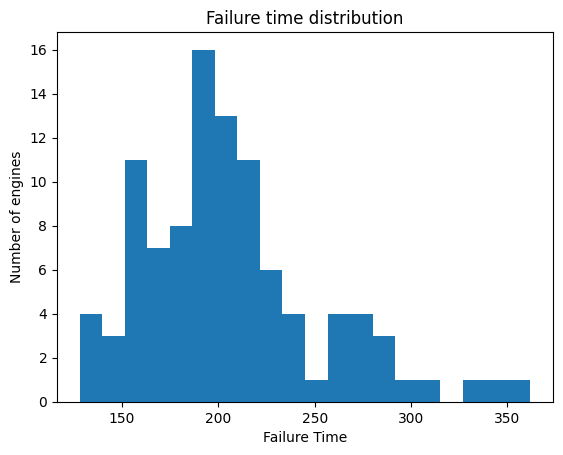

In [11]:
plt.hist(failure_time,bins=20)
plt.title('Failure time distribution')
plt.xlabel('Failure Time')
plt.ylabel('Number of engines')
plt.show()

In [15]:
# Fitting Weibull Distribution using MLE
shape,loc,scale=weibull_min.fit(failure_time,floc=0)
print(f'Estimated shape parameter:{shape:.4f}')
print(f'Estimated scale parameter:{scale:.4f}') 
print('Interpretation:')
if shape<1:
    print("the failure decreses over time, indicating early failures")
elif shape==1:
    print("the failure rate is constant over time,indicating random failures")
else:
    print("the failure rate is increasing over time, indicating wear-out failures")

Estimated shape parameter:4.4087
Estimated scale parameter:225.0259
Interpretation:
the failure rate is increasing over time, indicating wear-out failures


In [20]:
#Calculating the  functions for the fitted Weibull distribution
t=np.linspace(1,400,1000)
# Weibull functions
def weibull_pdf(t,beta,eta):
    return (beta/eta) * (t/eta)**(beta-1) * np.exp(-(t/eta)**beta)
def weibull_cdf(t,beta,eta):
    return 1-np.exp(-(t/eta)**beta)
def weibull_reliability(t, beta, eta):
    return np.exp(-(t/eta)**beta)
def weibull_hazard(t,beta,eta):
    return (beta/eta)*(t/eta)**(beta-1)

beta, eta = shape, scale

pdf  = weibull_pdf(t, beta, eta)
cdf  = weibull_cdf(t, beta, eta)
R    = weibull_reliability(t, beta, eta)
h    = weibull_hazard(t, beta, eta)

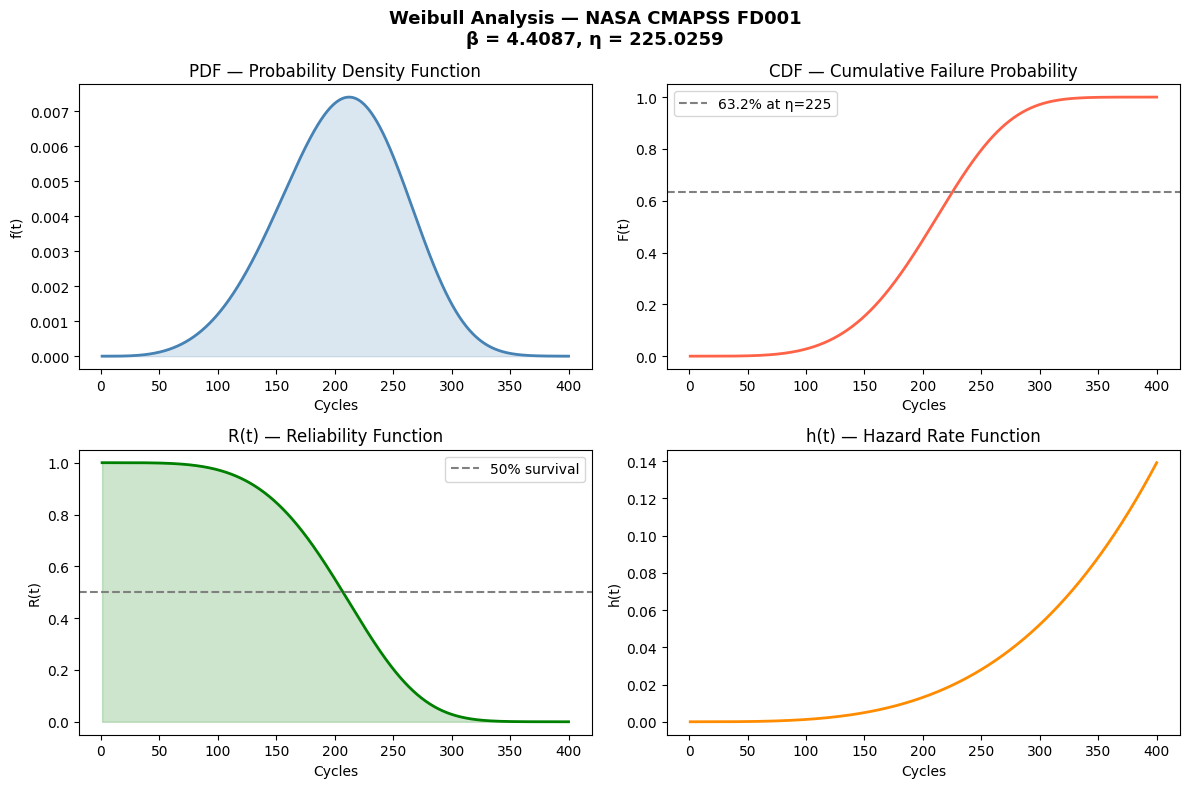

In [21]:
# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(f'Weibull Analysis — NASA CMAPSS FD001\nβ = {beta:.4f}, η = {eta:.4f}', 
             fontsize=13, fontweight='bold')

axes[0,0].plot(t, pdf, color='steelblue', linewidth=2)
axes[0,0].set_title('PDF — Probability Density Function')
axes[0,0].set_xlabel('Cycles'); axes[0,0].set_ylabel('f(t)')
axes[0,0].fill_between(t, pdf, alpha=0.2, color='steelblue')

axes[0,1].plot(t, cdf, color='tomato', linewidth=2)
axes[0,1].set_title('CDF — Cumulative Failure Probability')
axes[0,1].set_xlabel('Cycles'); axes[0,1].set_ylabel('F(t)')
axes[0,1].axhline(0.632, color='gray', linestyle='--', label=f'63.2% at η={eta:.0f}')
axes[0,1].legend()

axes[1,0].plot(t, R, color='green', linewidth=2)
axes[1,0].set_title('R(t) — Reliability Function')
axes[1,0].set_xlabel('Cycles'); axes[1,0].set_ylabel('R(t)')
axes[1,0].axhline(0.5, color='gray', linestyle='--', label='50% survival')
axes[1,0].fill_between(t, R, alpha=0.2, color='green')
axes[1,0].legend()

axes[1,1].plot(t, h, color='darkorange', linewidth=2)
axes[1,1].set_title('h(t) — Hazard Rate Function')
axes[1,1].set_xlabel('Cycles'); axes[1,1].set_ylabel('h(t)')

plt.tight_layout()
plt.show()

In [22]:
from scipy.special import gamma

# --- MTTF (Mean Time To Failure) ---
# Analytical formula for Weibull: MTTF = eta * Gamma(1 + 1/beta)
MTTF = eta * gamma(1 + 1/beta)

# --- B-Life calculations ---
# BX life = time at which X% of population has failed
# Derived by inverting the CDF: t = eta * (-ln(1-X/100))^(1/beta)
def b_life(x_percent, beta, eta):
    return eta * (-np.log(1 - x_percent/100))**(1/beta)

B10 = b_life(10, beta, eta)
B50 = b_life(50, beta, eta)
B90 = b_life(90, beta, eta)

In [23]:
print("WEIBULL RELIABILITY METRICS")
print(f"  Shape (β)        : {beta:.4f}")
print(f"  Scale (η)        : {eta:.4f} cycles")
print(f"  MTTF             : {MTTF:.2f} cycles")
print(f"  B10 Life         : {B10:.2f} cycles")
print(f"  B50 Life (Median): {B50:.2f} cycles")
print(f"  B90 Life         : {B90:.2f} cycles")
print("\nInterpretation of B-Life:")
print(f"\n  10% of engines fail BEFORE cycle {B10:.0f}")
print(f"  50% of engines fail BEFORE cycle {B50:.0f}")
print(f"  90% of engines fail BEFORE cycle {B90:.0f}")


WEIBULL RELIABILITY METRICS
  Shape (β)        : 4.4087
  Scale (η)        : 225.0259 cycles
  MTTF             : 205.11 cycles
  B10 Life         : 135.07 cycles
  B50 Life (Median): 207.08 cycles
  B90 Life         : 271.89 cycles

Interpretation of B-Life:

  10% of engines fail BEFORE cycle 135
  50% of engines fail BEFORE cycle 207
  90% of engines fail BEFORE cycle 272


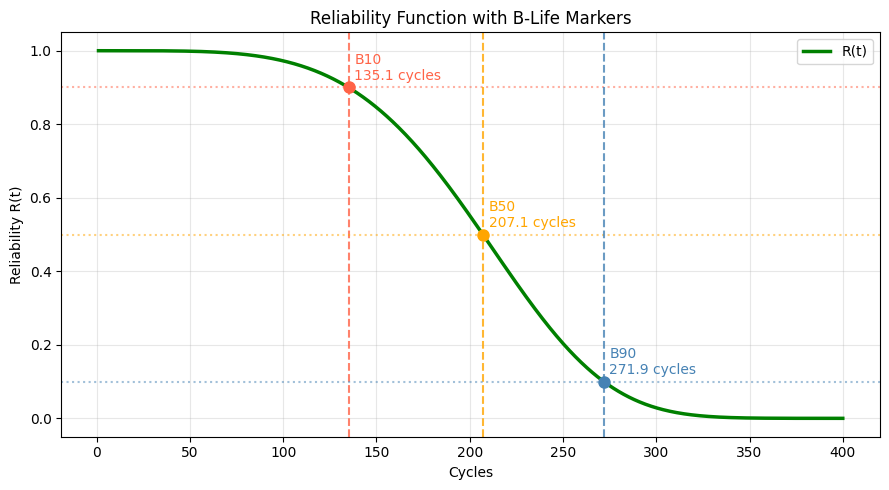

In [25]:
plt.figure(figsize=(9, 5))
plt.plot(t, R, color='green', linewidth=2.5, label='R(t)')

for bx, label, col in [
    (B10, 'B10', 'tomato'),
    (B50, 'B50', 'orange'),
    (B90, 'B90', 'steelblue')
]:
    y = weibull_reliability(bx, beta, eta)

    plt.axvline(bx, color=col, linestyle='--', alpha=0.8)
    plt.axhline(y, color=col, linestyle=':', alpha=0.5)
    plt.plot(bx, y, 'o', color=col, markersize=8)

    # Add text label
    plt.text(
        bx + 3,          # slightly to the right
        y + 0.02,         # slightly above
        f"{label}\n{bx:.1f} cycles",
        color=col,
        fontsize=10
    )

plt.xlabel("Cycles")
plt.ylabel("Reliability R(t)")
plt.title("Reliability Function with B-Life Markers")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

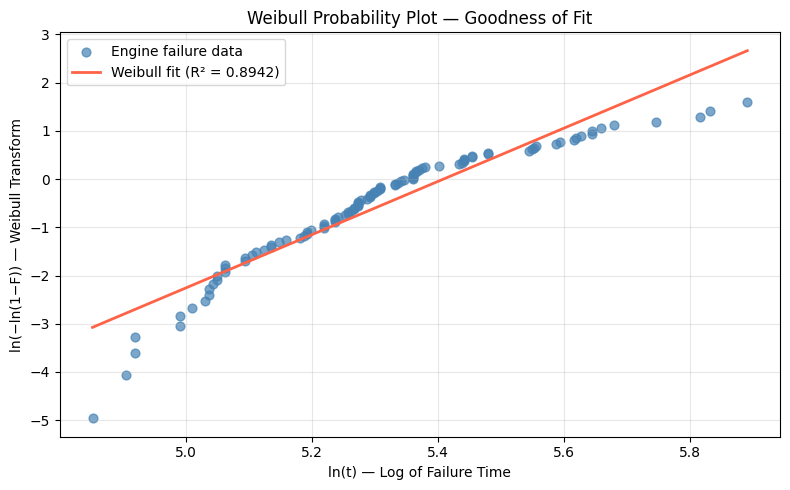

R² of Weibull fit: 0.8942
R² > 0.95 indicates good Weibull fit


In [28]:
# --- Weibull Probability Plot ---
# Sort failure times
t_sorted = np.sort(failure_time)
n = len(t_sorted)

# Median rank estimator (Benard's approximation) — standard in reliability
median_ranks = (np.arange(1, n+1) - 0.3) / (n + 0.4)

# Linearize: ln(t) vs ln(ln(1/(1-F)))
x = np.log(t_sorted)
y = np.log(-np.log(1 - median_ranks))

# Fit a line through the linearized points
coeffs = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = np.polyval(coeffs, x_line)

# R-squared
y_pred = np.polyval(coeffs, x)
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - y.mean())**2)
r_squared = 1 - ss_res/ss_tot

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='steelblue', alpha=0.7, s=40, label='Engine failure data')
plt.plot(x_line, y_line, color='tomato', linewidth=2, 
         label=f'Weibull fit (R² = {r_squared:.4f})')

plt.xlabel('ln(t) — Log of Failure Time')
plt.ylabel('ln(−ln(1−F)) — Weibull Transform')
plt.title('Weibull Probability Plot — Goodness of Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"R² of Weibull fit: {r_squared:.4f}")
print("R² > 0.95 indicates good Weibull fit")

3-param Weibull:
  Shape (β) : 1.8300
  Location (γ) : 125.1901  ← minimum failure time
  Scale (η) : 91.2945


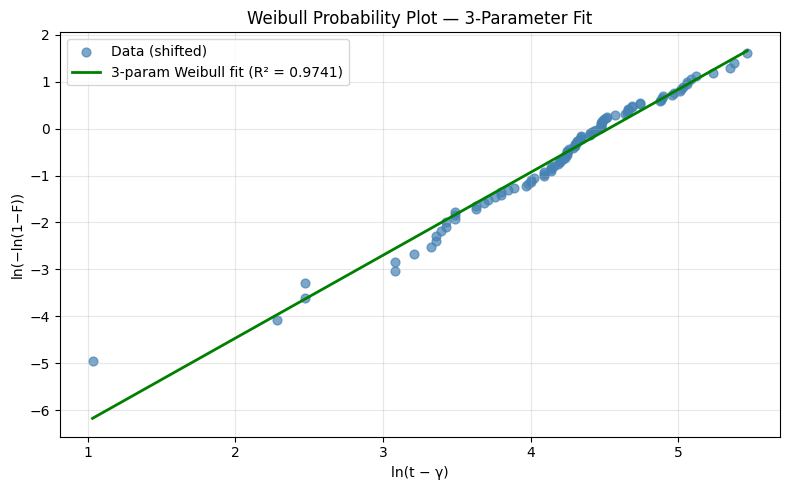


2-param R²: 0.8942
3-param R²: 0.9741
Improvement: 0.0799


In [29]:
# 3-parameter Weibull (adds a location/threshold parameter γ)
# Useful when failures cannot occur before some minimum time
shape3, loc3, scale3 = weibull_min.fit(failure_time)  # remove floc=0 this time

print(f"3-param Weibull:")
print(f"  Shape (β) : {shape3:.4f}")
print(f"  Location (γ) : {loc3:.4f}  ← minimum failure time")
print(f"  Scale (η) : {scale3:.4f}")

# Re-plot probability plot with 3-param fit
median_ranks = (np.arange(1, n+1) - 0.3) / (n + 0.4)
t_sorted_shifted = t_sorted - loc3  # shift by gamma

x3 = np.log(t_sorted_shifted)
y3 = np.log(-np.log(1 - median_ranks))

coeffs3 = np.polyfit(x3, y3, 1)
x_line3 = np.linspace(x3.min(), x3.max(), 100)
y_line3 = np.polyval(coeffs3, x_line3)

y_pred3 = np.polyval(coeffs3, x3)
ss_res3 = np.sum((y3 - y_pred3)**2)
ss_tot3 = np.sum((y3 - y3.mean())**2)
r_squared3 = 1 - ss_res3/ss_tot3

plt.figure(figsize=(8,5))
plt.scatter(x3, y3, color='steelblue', alpha=0.7, s=40, label='Data (shifted)')
plt.plot(x_line3, y_line3, color='green', linewidth=2,
         label=f'3-param Weibull fit (R² = {r_squared3:.4f})')
plt.xlabel('ln(t − γ)')
plt.ylabel('ln(−ln(1−F))')
plt.title('Weibull Probability Plot — 3-Parameter Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n2-param R²: 0.8942")
print(f"3-param R²: {r_squared3:.4f}")
print(f"Improvement: {r_squared3 - 0.8942:.4f}")

In [31]:

print("     FINAL WEIBULL ANALYSIS SUMMARY")
print(f"\n  Dataset     : NASA CMAPSS FD001")
print(f"  Engines     : 100 (all run-to-failure)")
print(f"  Failure range: {failure_time.min()}–{failure_time.max()} cycles")
print()
print(f"  --- 2-Parameter Weibull ---")
print(f"  β = {beta:.4f}, η = {eta:.4f}")
print(f"  R² = 0.8942")
print()
print(f"  --- 3-Parameter Weibull (Best Fit) ---")
print(f"  β = {shape3:.4f}, η = {scale3:.4f}, γ = {loc3:.4f}")
print(f"  R² = {r_squared3:.4f}")
print()
print(f"  --- Reliability Metrics (2-param) ---")
print(f"  MTTF : {MTTF:.2f} cycles")
print(f"  B10  : {B10:.2f} cycles  ← maintenance threshold")
print(f"  B50  : {B50:.2f} cycles")
print(f"  B90  : {B90:.2f} cycles")

     FINAL WEIBULL ANALYSIS SUMMARY

  Dataset     : NASA CMAPSS FD001
  Engines     : 100 (all run-to-failure)
  Failure range: 128–362 cycles

  --- 2-Parameter Weibull ---
  β = 4.4087, η = 225.0259
  R² = 0.8942

  --- 3-Parameter Weibull (Best Fit) ---
  β = 1.8300, η = 91.2945, γ = 125.1901
  R² = 0.9741

  --- Reliability Metrics (2-param) ---
  MTTF : 205.11 cycles
  B10  : 135.07 cycles  ← maintenance threshold
  B50  : 207.08 cycles
  B90  : 271.89 cycles
